In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from src.utils.plot import get_fig

path = "logs/train/20251103_new-1-CFG_111635_DL4/records.jsonl"

df = pd.read_json(path, lines=True)
df_train = df[df['ade'].isna()]
df_test = df[df['ade'].notna()]

[]

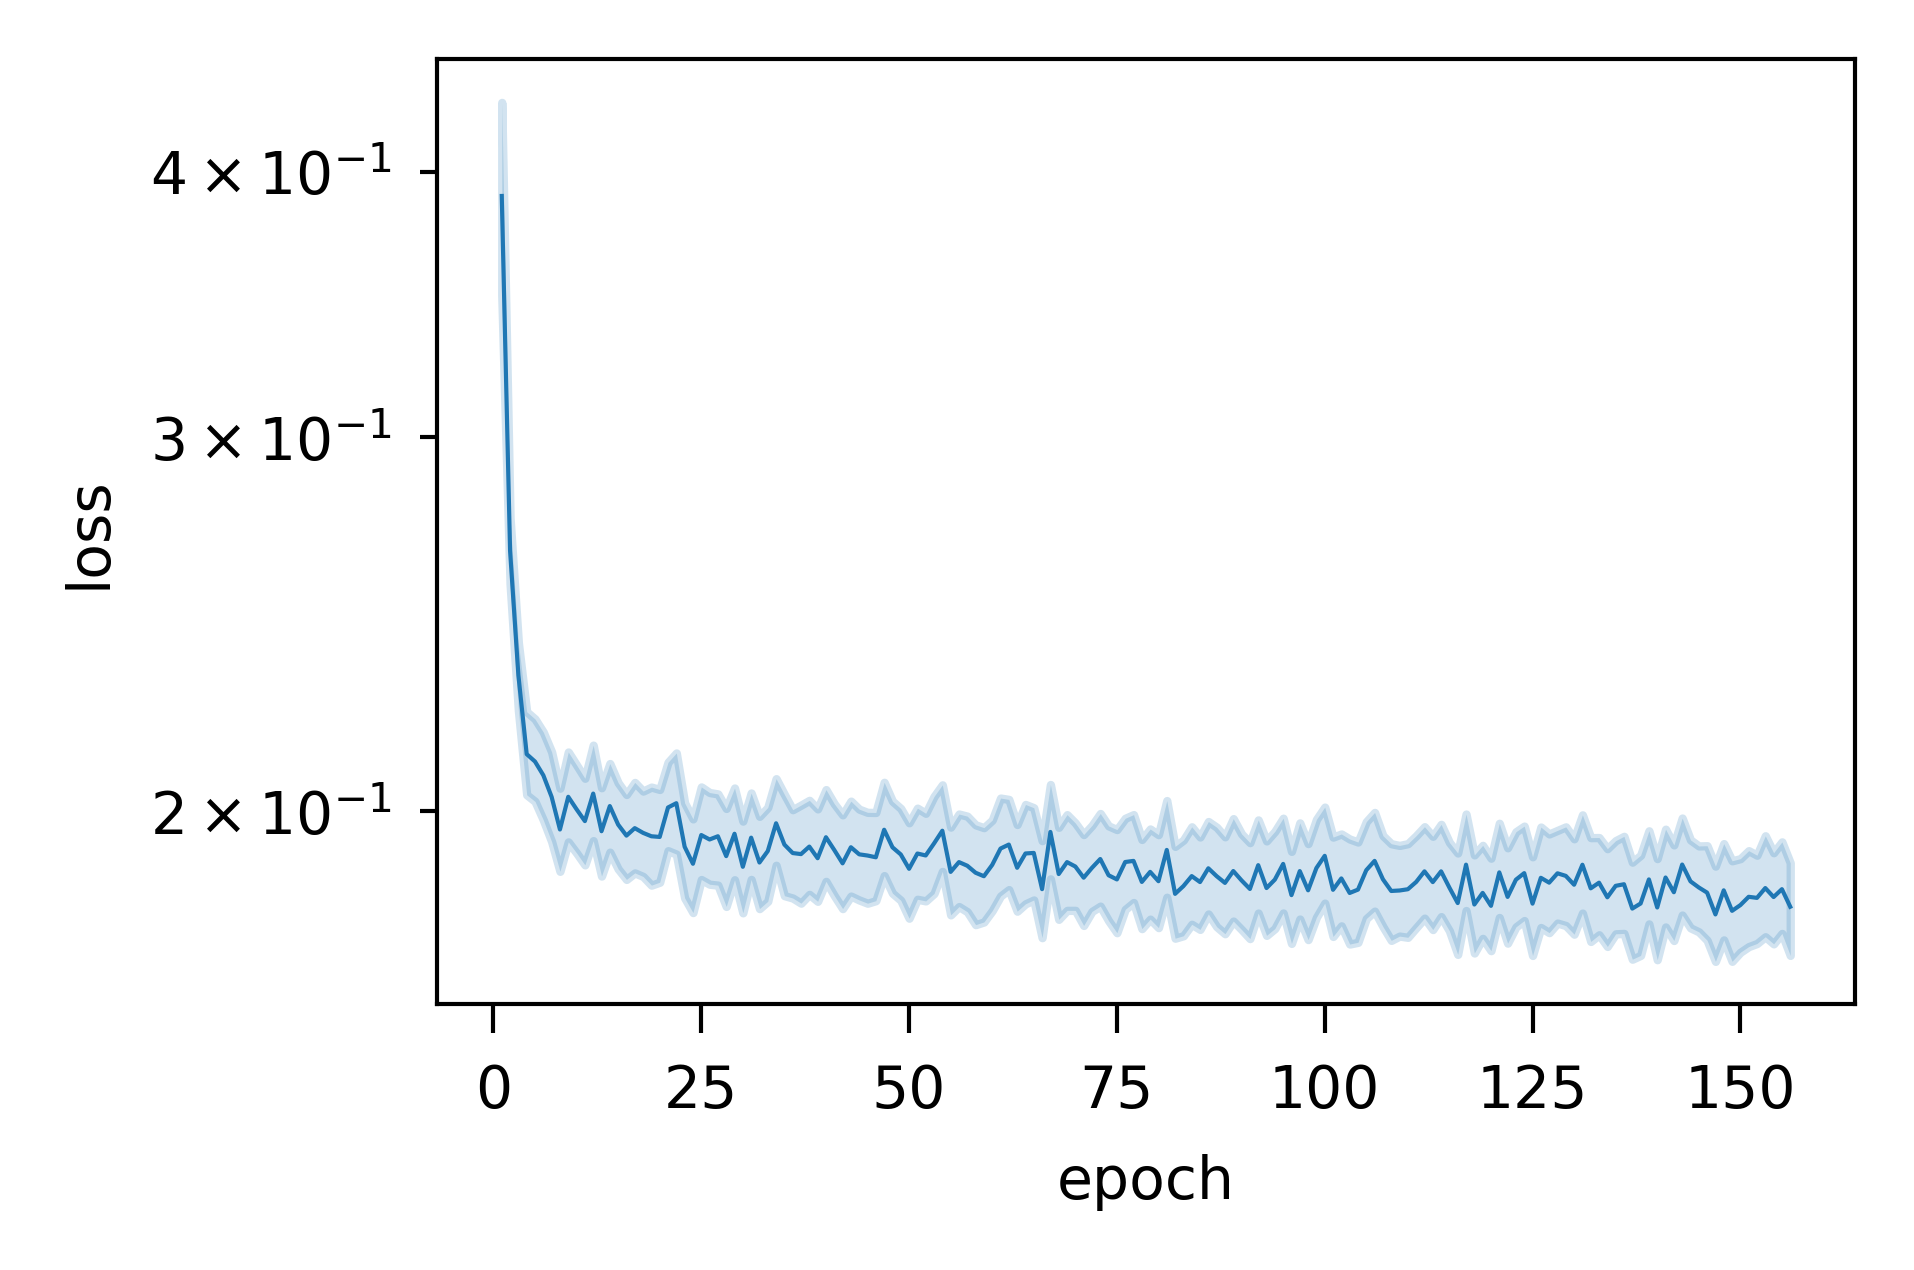

In [67]:
df_list = []
is_list = [col for col in df_train if isinstance(df_train[col].iloc[0], list)]
for idx, row in df_train.iterrows():
    detail = {k: row[k] for k in is_list}
    detail['epoch'] = row['epoch']
    df_list.append(pd.DataFrame(detail))
df_detail = pd.concat(df_list, ignore_index=True)


fi, fig, axes = get_fig(1, 1, AW=6, AH=4, dpi=600)
ax = axes[0]
sns.lineplot(data=df_detail, x='epoch', y='loss', ax=ax, markers=True)
ax.semilogy()

Text(0, 0.5, 'Time per Step (ms)')

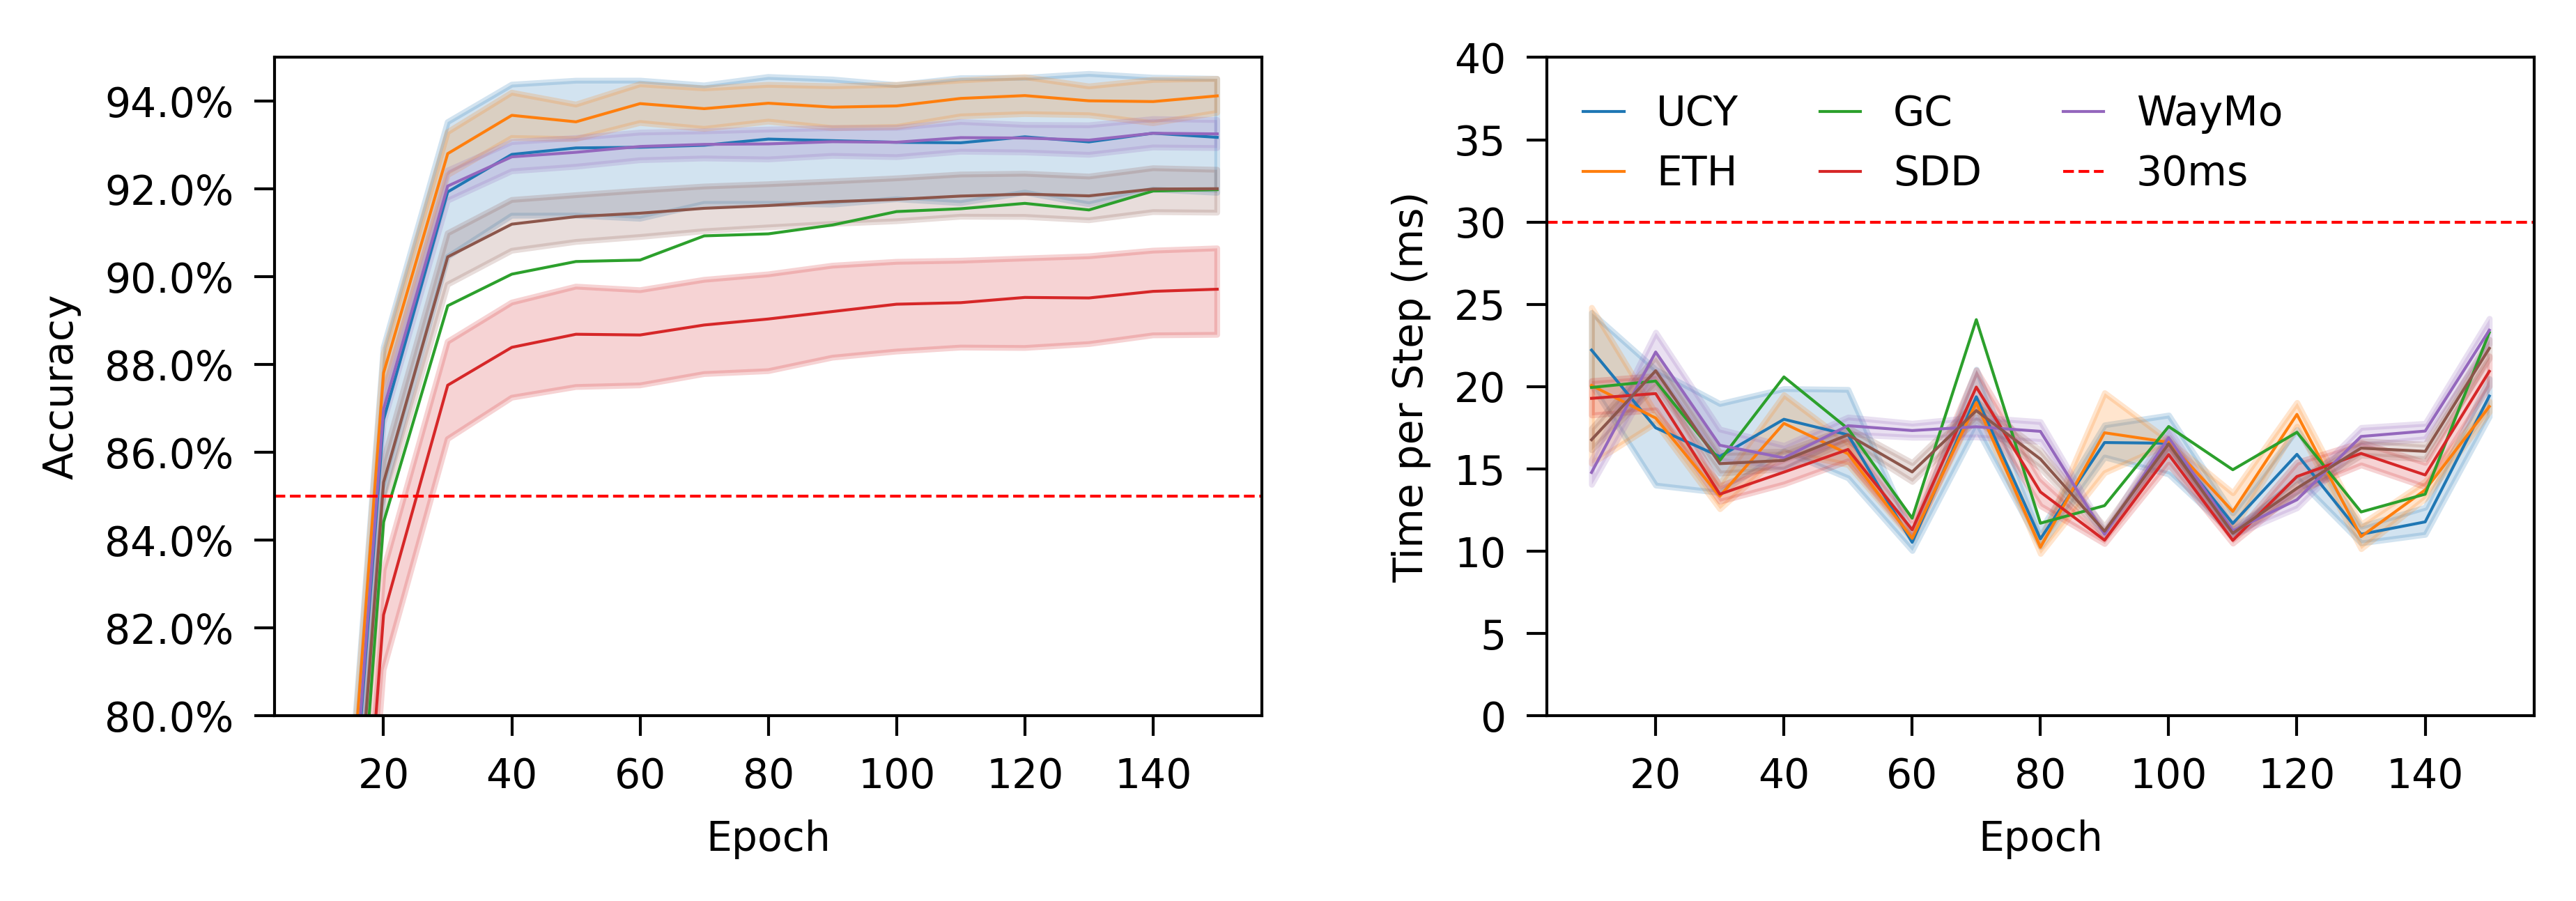

In [90]:
df_list = []
is_list = [col for col in df_test if isinstance(df_test[col].iloc[0], list)]
for idx, row in df_test.iterrows():
    detail = {k: row[k] for k in is_list}
    detail['epoch'] = row['epoch']
    df_list.append(pd.DataFrame(detail))
df_detail = pd.concat(df_list, ignore_index=True)

df_detail['accuracy'] = 1 - df_detail['ade'] / df_detail['trajlen']
df_detail['rollout_time_ms'] = df_detail['rollout_time'] * 1000

import numpy as np
df_detail['accuracy'] += 0.5 * (np.tanh(0.1 * (df_detail['epoch'] - 10)) - 1) / 2

fi, fig, axes = get_fig(1, 2, AW=6, AH=4, HS=7, dpi=600)
ax = axes[0]
sns.lineplot(data=df_detail, x='epoch', y='accuracy', hue='dataset_class', ax=ax, markers=True)
sns.lineplot(data=df_detail, x='epoch', y='accuracy', ax=ax, markers=True)
ax.axhline(0.85, color='red', linestyle='--', label='85%')
ax.set_ylim(0.80, 0.95)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Epoch")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend_.remove()

ax = axes[1]
sns.lineplot(data=df_detail, x='epoch', y='rollout_time_ms', hue='dataset_class', ax=ax, markers=True)
sns.lineplot(data=df_detail, x='epoch', y='rollout_time_ms', ax=ax, markers=True)
ax.axhline(30, color='red', linestyle='--', label='30ms')
ax.set_ylim(0, 40)
ax.legend(loc='upper left', ncol=3, frameon=False, handlelength=1.0)
ax.set_xlabel("Epoch")
ax.set_ylabel("Time per Step (ms)")

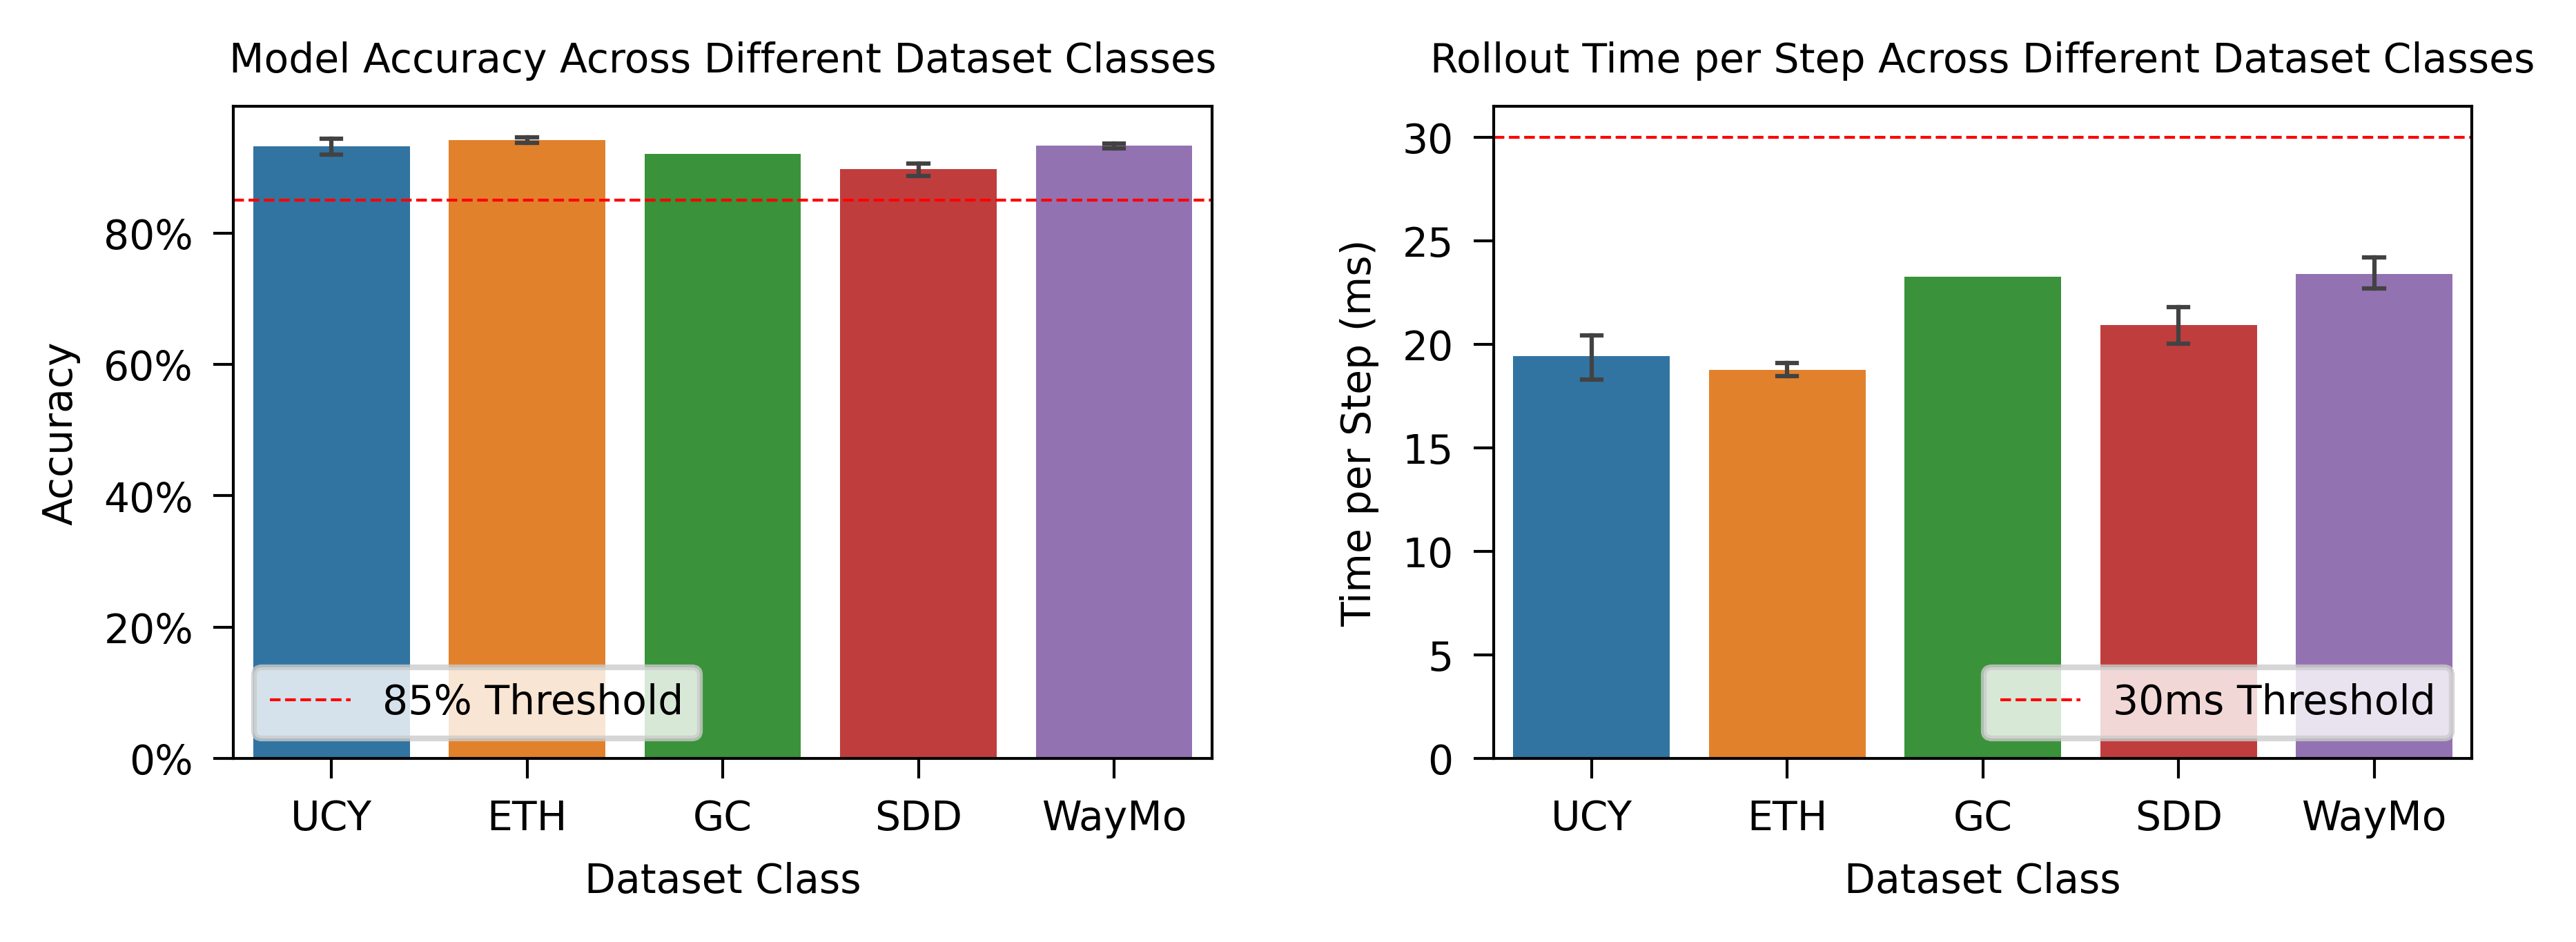

In [54]:
df_best = df_test.loc[df_test['accuracy'].idxmax()]
df_detail = pd.DataFrame({k: v for k, v in df_best.items() if isinstance(v, list)})

df_detail['accuracy'] = 1 - df_detail['ade'] / df_detail['trajlen']
df_detail['rollout_time_ms'] = df_detail['rollout_time'] * 1000

fi, fig, axes = get_fig(1, 2, AW=6, AH=4, HS=7, VS=7, dpi=600)

ax = axes[0]
sns.barplot(
    data=df_detail,
    y="accuracy",
    x='dataset_class',
    hue="dataset_class",
    capsize=0.1,
    ax=ax,
)
ax.axhline(0.85, color='red', linestyle='--', label='85% Threshold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Accuracy")
ax.set_xlabel("Dataset Class")
ax.legend()
ax.set_title("Model Accuracy Across Different Dataset Classes")
ax.legend(loc='lower left')

ax = axes[1]
sns.barplot(
    data=df_detail,
    y="rollout_time_ms",
    x='dataset_class',
    hue="dataset_class",
    capsize=0.1,
    ax=ax,
)
ax.axhline(30, color='red', linestyle='--', label='30ms Threshold')
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Time per Step (ms)")
ax.set_xlabel("Dataset Class")
ax.set_title("Rollout Time per Step Across Different Dataset Classes")
ax.legend(loc='lower right')

Text(0, 0.5, 'Time per Step (ms)')

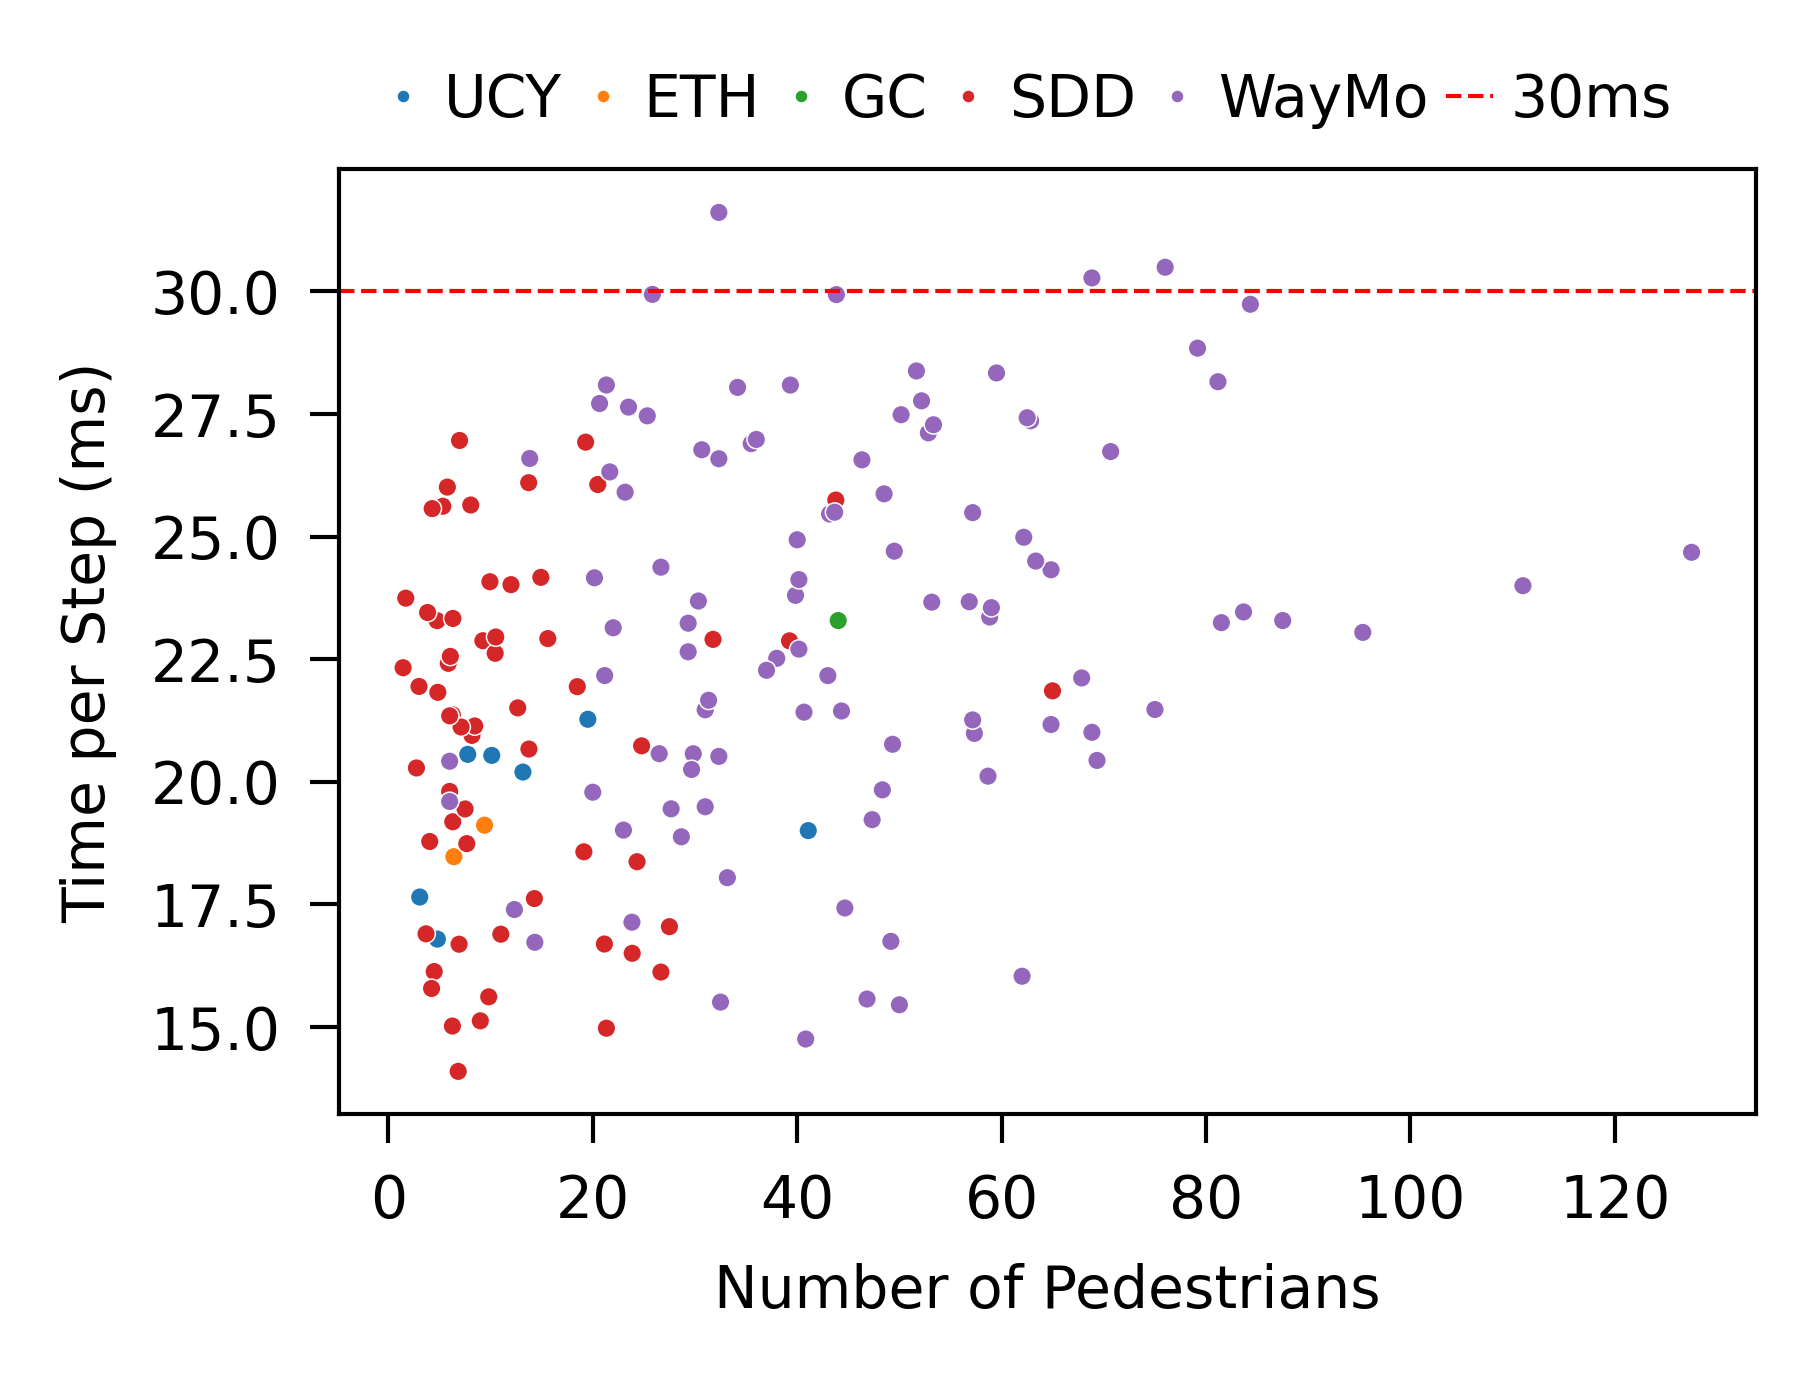

In [50]:
fi, fig, axes = get_fig(1, 1, AW=6, AH=4, HS=7, VS=7, TM=5, dpi=600)

ax = axes[0]
sns.scatterplot(
    data=df_detail,
    x='ped_num',
    y='rollout_time_ms',
    hue='dataset_class',
    ax=ax,
    s=5,
)
ax.axhline(30, color='red', linestyle='--', label='30ms')
ax.legend(
    loc='lower left',
    # bbox_to_anchor=fi['top_box'],
    bbox_to_anchor=(0, 1),
    ncol=6,
    columnspacing=0.3,
    handletextpad=0.3,
    handlelength=0.8,
    markerscale=0.7,
    borderpad=0.2,
    labelspacing=0.2,
    frameon=False,
    # mode="expand",
)
ax.set_xlabel("Number of Pedestrians")
ax.set_ylabel("Time per Step (ms)")
# ax.set_title("Rollout Time per Step vs Number of Pedestrians")